# Modellöversikt & Databerättelse — Diamond Prices

## Vad gör denna notebook?
Detta är vår **sammanställning** — ingen ny modellträning utan en
komplett översikt av alla experiment från notebook 02–05.

Vi svarar på projektets huvudfråga:

> **Vad bestämmer priset på en diamant, och hur väl kan maskininlärning
> förutsäga det?**

## Struktur
1. Sammanställning av alla modellresultat
2. Visuell jämförelse
3. Vilken modell är bäst — och varför?
4. Insikter om datasetet
5. Databerättelsen — slutsatser och rekommendationer

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

OUTPUT_DIR  = "../outputs/models/"
RESULTS_DIR = "../outputs/results/"

print("✅ Imports klar!")

✅ Imports klar!


## 0. Ladda resultat från JSON

Alla modellresultat laddas från `outputs/results/` — sparade dynamiskt
av respektive notebook. På så sätt behöver vi aldrig uppdatera siffror
manuellt här om modellerna tränas om.

In [2]:
# ── Ladda resultat från JSON ───────────────────────────────────────────────────
with open(f"{RESULTS_DIR}results_logreg.json") as f:
    r_logreg = json.load(f)

with open(f"{RESULTS_DIR}results_knn_classifier.json") as f:
    r_knn_clf = json.load(f)

with open(f"{RESULTS_DIR}results_knn_regressor.json") as f:
    r_knn_reg = json.load(f)

with open(f"{RESULTS_DIR}results_pca_umap.json") as f:
    r_pca_umap = json.load(f)

print("✅ Alla JSON-filer laddade!")
print(f"   logreg        : {list(r_logreg.keys())}")
print(f"   knn_classifier: {list(r_knn_clf.keys())}")
print(f"   knn_regressor : {list(r_knn_reg.keys())}")
print(f"   pca_umap      : {list(r_pca_umap.keys())}")

✅ Alla JSON-filer laddade!
   logreg        : ['logreg_alla_features', 'logreg_reducerad']
   knn_classifier: ['knn_baseline', 'knn_optimerad']
   knn_regressor : ['knn_reg_baseline', 'knn_reg_optimerad']
   pca_umap      : ['pca', 'umap', 'pca_explained_variance']


## 1. Sammanställning — alla klassificeringsmodeller

Vi har testat **10 modellkonfigurationer** för att klassificera diamanter
som billiga (≤ $2,401) eller dyra (> $2,401).

Alla modeller tränades på samma data (80/20 split, random_state=42)
och utvärderades på samma testset (10,755 diamanter).

In [3]:
# ── Ladda klassificeringsresultat dynamiskt från JSON ──────────────────────────
pca_n2  = next(r for r in r_pca_umap["pca"]  if r["n_components"] == 2)
pca_n5  = next(r for r in r_pca_umap["pca"]  if r["n_components"] == 5)
umap_n2 = next(r for r in r_pca_umap["umap"] if r["n_components"] == 2)
umap_n5 = next(r for r in r_pca_umap["umap"] if r["n_components"] == 5)

results = pd.DataFrame([
    {"Modell": "Logistisk Regression (9D)", "Accuracy": r_logreg["logreg_alla_features"]["accuracy"], "AUC": r_logreg["logreg_alla_features"]["auc"], "Typ": "Rå"},
    {"Modell": "KNN k=5 baseline (9D)",     "Accuracy": r_knn_clf["knn_baseline"]["accuracy"],        "AUC": r_knn_clf["knn_baseline"]["auc"],        "Typ": "Rå"},
    {"Modell": "KNN optimerad (9D)",        "Accuracy": r_knn_clf["knn_optimerad"]["accuracy"],       "AUC": r_knn_clf["knn_optimerad"]["auc"],       "Typ": "Rå"},
    {"Modell": "PCA n=5 + LogReg",          "Accuracy": pca_n5["logreg_acc"],                        "AUC": pca_n5["logreg_auc"],                    "Typ": "PCA"},
    {"Modell": "PCA n=5 + KNN",             "Accuracy": pca_n5["knn_acc"],                           "AUC": pca_n5["knn_auc"],                       "Typ": "PCA"},
    {"Modell": "PCA n=2 + LogReg",          "Accuracy": pca_n2["logreg_acc"],                        "AUC": pca_n2["logreg_auc"],                    "Typ": "PCA"},
    {"Modell": "PCA n=2 + KNN",             "Accuracy": pca_n2["knn_acc"],                           "AUC": pca_n2["knn_auc"],                       "Typ": "PCA"},
    {"Modell": "UMAP n=5 + KNN",            "Accuracy": umap_n5["knn_acc"],                          "AUC": umap_n5["knn_auc"],                      "Typ": "UMAP"},
    {"Modell": "UMAP n=2 + KNN",            "Accuracy": umap_n2["knn_acc"],                          "AUC": umap_n2["knn_auc"],                      "Typ": "UMAP"},
    {"Modell": "UMAP n=5 + LogReg",         "Accuracy": umap_n5["logreg_acc"],                       "AUC": umap_n5["logreg_auc"],                   "Typ": "UMAP"},
    {"Modell": "UMAP n=2 + LogReg",         "Accuracy": umap_n2["logreg_acc"],                       "AUC": umap_n2["logreg_auc"],                   "Typ": "UMAP"},
])

results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
results.index = results.index + 1

print("📊 Rankad modellöversikt — Klassificering:")
print(results.to_string())

📊 Rankad modellöversikt — Klassificering:
                       Modell  Accuracy     AUC   Typ
1   Logistisk Regression (9D)    0.9756  0.9974    Rå
2            PCA n=5 + LogReg    0.9747  0.9973   PCA
3          KNN optimerad (9D)    0.9739  0.9969    Rå
4               PCA n=5 + KNN    0.9739  0.9965   PCA
5       KNN k=5 baseline (9D)    0.9685  0.9931    Rå
6              UMAP n=5 + KNN    0.9613  0.9934  UMAP
7              UMAP n=2 + KNN    0.9492  0.9886  UMAP
8               PCA n=2 + KNN    0.9389  0.9837   PCA
9            PCA n=2 + LogReg    0.9223  0.9823   PCA
10          UMAP n=5 + LogReg    0.9083  0.9605  UMAP
11          UMAP n=2 + LogReg    0.8524  0.9081  UMAP


## 2. Visuell jämförelse — Accuracy & AUC

Grupperat per metod (Rå, PCA, UMAP) för att visa trender.

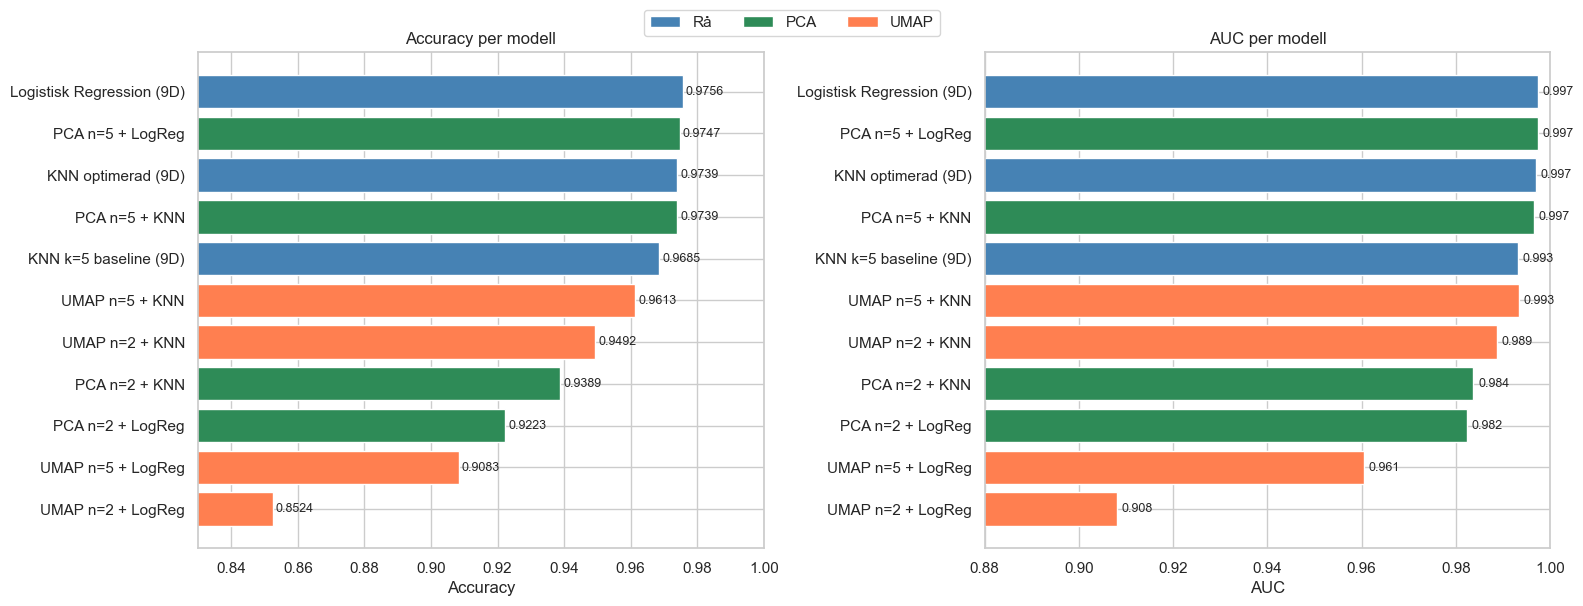

In [4]:
# ── Grouped barplot — Accuracy per modell, färgat per Typ ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Accuracy ───────────────────────────────────────────────────────────────────
colors_map = {"Rå": "steelblue", "PCA": "seagreen", "UMAP": "coral"}
bar_colors = [colors_map[t] for t in results["Typ"]]

axes[0].barh(results["Modell"][::-1], results["Accuracy"][::-1],
             color=bar_colors[::-1])
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Accuracy per modell")
axes[0].set_xlim(0.83, 1.0)

# Lägg till värden
for i, (acc, modell) in enumerate(zip(results["Accuracy"][::-1], results["Modell"][::-1])):
    axes[0].text(acc + 0.001, i, f"{acc:.4f}", va="center", fontsize=9)

# ── AUC ────────────────────────────────────────────────────────────────────────
axes[1].barh(results["Modell"][::-1], results["AUC"][::-1],
             color=bar_colors[::-1])
axes[1].set_xlabel("AUC")
axes[1].set_title("AUC per modell")
axes[1].set_xlim(0.88, 1.0)

for i, (auc, modell) in enumerate(zip(results["AUC"][::-1], results["Modell"][::-1])):
    axes[1].text(auc + 0.001, i, f"{auc:.3f}", va="center", fontsize=9)

# Gemensam legend
legend_elements = [Patch(facecolor=c, label=t) for t, c in colors_map.items()]
fig.legend(handles=legend_elements, loc="upper center", ncol=3,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}story_01_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. KNN Regressor — priset i kronor och ören

Utöver klassificering testade vi KNN som **Regressor** — att förutsäga
det exakta priset istället för bara billig/dyr.

Detta är lärarens "extra" — KNN kan användas som Regressor, inte bara
som Classifier.

📊 KNN Regressor — Regressionsresultat:
                                            Modell  RMSE  MAE     R²
                      KNN Regressor baseline (k=5)   703  373 0.9682
KNN Regressor optimerad (k=9, manhattan, distance)   641  326 0.9736


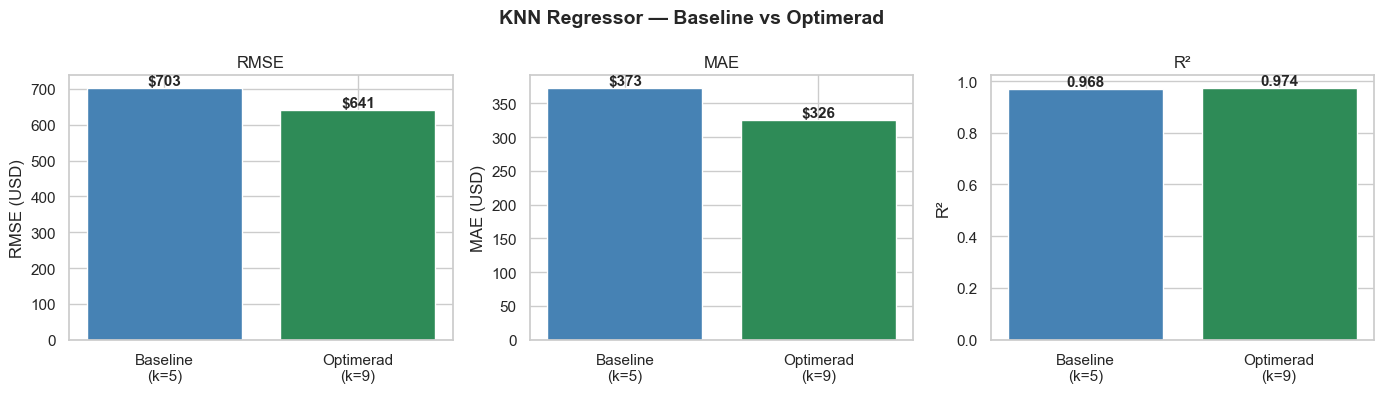

In [5]:
# ── Ladda regressionsresultat dynamiskt från JSON ──────────────────────────────
b = r_knn_reg["knn_reg_baseline"]
o = r_knn_reg["knn_reg_optimerad"]

reg_results = pd.DataFrame([
    {"Modell": "KNN Regressor baseline (k=5)",
     "RMSE": round(b["rmse"]), "MAE": round(b["mae"]), "R²": b["r2"]},
    {"Modell": f"KNN Regressor optimerad (k={o['params']['n_neighbors']}, {o['params']['metric']}, {o['params']['weights']})",
     "RMSE": round(o["rmse"]), "MAE": round(o["mae"]), "R²": o["r2"]},
])

print("📊 KNN Regressor — Regressionsresultat:")
print(reg_results.to_string(index=False))

# ── Visuell jämförelse ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = ["Baseline\n(k=5)", f"Optimerad\n(k={o['params']['n_neighbors']})"]
colors = ["steelblue", "seagreen"]

for ax, metric, vals, ylabel in [
    (axes[0], "RMSE", [round(b["rmse"]), round(o["rmse"])], "RMSE (USD)"),
    (axes[1], "MAE",  [round(b["mae"]),  round(o["mae"])],  "MAE (USD)"),
    (axes[2], "R²",   [b["r2"],          o["r2"]],          "R²"),
]:
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        fmt = f"${val:,}" if metric != "R²" else f"{val:.3f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                fmt, ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.suptitle("KNN Regressor — Baseline vs Optimerad", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}story_02_regressor_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Databerättelsen — vad lärde vi oss?

### Kapitel 1: Datasetet
Vi analyserade **53,772 diamanter** med 9 egenskaper vardera.
Det viktigaste fyndet i EDA var att **karatvikt (carat)** korrelerar
0.92 med priset — vikt är överlägset den viktigaste faktorn.

Vi hittade också **Simpsons paradox** — bättre slipning (cut), färg
(color) och klarhet (clarity) korrelerar *negativt* med pris.
Förklaringen: stora tunga diamanter slipas oftare med lägre kvalitet
men säljs ändå dyrare tack vare sin storlek.

### Kapitel 2: Klassificering — billig eller dyr?
Vi satte prisgränsen vid medianen ($2,401) och testade:
- **Logistisk Regression** — vår baseline. 97.6% accuracy, AUC 0.997
- **KNN Classifier** — 96.9% baseline → 97.4% efter optimering
- Båda modellerna är extremt starka — datan är lättseparerad

**Optimering via GridSearchCV** visade att Manhattan-avstånd och
distance-vikter konsekvent vinner för KNN — oavsett om det är
klassificering eller regression.

### Kapitel 3: Regression — vad kostar diamanten?
KNN som Regressor förutsäger priset till **±$326 i genomsnitt** (MAE)
och förklarar **97.4% av prisvariationen** (R²). Residualanalysen
visade att modellen är välkalibrerad men underskattar de dyraste
diamanterna — en inbyggd KNN-begränsning.

### Kapitel 4: Dimensionsreduktion — PCA vs UMAP
- **PCA med 5 komponenter** ≈ samma resultat som alla 9 features
- **UMAP visualiserar vackert** men försämrar klassificeringen
- Diamond-datan har en **fundamentalt linjär struktur** → PCA vinner

### Kapitel 5: Slutsats
> Den enklaste modellen vinner. Logistisk Regression med alla features
> ger 97.6% accuracy — ingen mer avancerad metod slår den meningsfullt.
> Det är ett dataset där **carat berättar nästan hela historien**.

## 5. Rekommendationer och framtida arbete

**Om detta vore ett riktigt affärsprojekt:**
1. **Logistisk Regression räcker** — den är snabb, tolkbar och lika bra
   som KNN. I produktion handlar det om hastighet och underhåll.
2. **KNN Regressor** ger mer nytta om kunden vill ha ett **prisestimat**
   istället för bara billig/dyr. MAE ±$326 är rimligt som riktpris.
3. **Feature-reducering är möjlig** — x, y, z kan tas bort utan
   prestationsförlust. Enklare modell = enklare att underhålla.
4. **Konfidensintervall** bör rapporteras för KNN Regressor —
   osäkerheten växer med priset.

**Framtida arbete:**
- Testa beslutsträd / Random Forest — kan fånga icke-linjära samband
  som KNN och LogReg missar
- Feature engineering: pris/karat-kvot, volym (x × y × z)
- Stratifiera modellen per prisintervall för bättre precision på dyra
  diamanter

In [6]:
# ── Avslutning ─────────────────────────────────────────────────────────────────
logreg_best  = r_logreg["logreg_alla_features"]
knn_reg_best = r_knn_reg["knn_reg_optimerad"]

print("=" * 60)
print("   💎 Diamond ML-projekt — KLART!")
print("=" * 60)

print(f"""
PROJEKTÖVERSIKT:
   Dataset:   53,772 diamanter, 9 features
   Notebooks: 6 st (EDA → LogReg → KNN → Regressor → PCA/UMAP → Story)

BÄSTA MODELLER:
   Klassificering: Logistisk Regression (acc {logreg_best['accuracy']*100:.1f}%, AUC {logreg_best['auc']:.3f})
   Regression:     KNN Regressor (R² {knn_reg_best['r2']:.3f}, MAE ${knn_reg_best['mae']:,.0f})

VIKTIGASTE INSIKTEN:
   Carat (karatvikt) förklarar nästan allt.
   Enkla modeller vinner på linjärt separerbar data.

PRESENTERAT AV:
   Constantine Diamantis och Nicklas Skoglund
   Jensen Yrkeshögskola — AI Developer
""")
print("=" * 60)

   💎 Diamond ML-projekt — KLART!

PROJEKTÖVERSIKT:
   Dataset:   53,772 diamanter, 9 features
   Notebooks: 6 st (EDA → LogReg → KNN → Regressor → PCA/UMAP → Story)

BÄSTA MODELLER:
   Klassificering: Logistisk Regression (acc 97.6%, AUC 0.997)
   Regression:     KNN Regressor (R² 0.974, MAE $326)

VIKTIGASTE INSIKTEN:
   Carat (karatvikt) förklarar nästan allt.
   Enkla modeller vinner på linjärt separerbar data.

PRESENTERAT AV:
   Constantine Diamantis och Nicklas Skoglund
   Jensen Yrkeshögskola — AI Developer

